<style>
@media print {
    body {
        font-family: "Times New Roman", serif;
        margin: 2cm;
    }

    .rendered_html {
        font-size: 12pt;
    }

    h1, h2, h3 {
        page-break-after: avoid;
    }

    div {
        page-break-inside: avoid;
    }
}
</style>


<div style="text-align: center;">

<br><br>

<h2 style="margin-bottom: 0;">Università di Pisa</h2>

<div style="margin-top: 4px; font-size: 22px;">
Corso di Laurea in Informatica
</div>

<br><br>

<h1 style="margin-bottom: 10px;">
BetFlow
</h1>

<h3 style="margin-top: 0; font-weight: normal;">
Analisi Comportamentale e Investigazione Forense su Blockchain
</h3>

<br>

<div style="font-size: 20px; max-width: 900px; margin: auto;">
<i>
Pipeline integrata per l’esplorazione statistica, la modellazione dei grafi e la de-anonimizzazione OSINT sul
      protocollo SatoshiDice
</i>
</div>

<br><br><br>

<div style="margin-top: 4px; font-size: 28px;">
Samuele Vasta
</div>
<div style=" font-size: 22px;">
Mat. 658190
</div>

<br>

<div style=" font-size: 18px;">Anno Accademico 2025/2026</div>

</div>

<hr style="margin-top: 50px; margin-bottom: 40px;">

## Abstract

Il presente documento analitico descrive la progettazione e l'implementazione di una pipeline di blockchain analytics finalizzata alla ricostruzione delle sessioni di gioco generate dal protocollo SatoshiDice. Attraverso l'applicazione congiunta della teoria dei grafi, dell'analisi statistica e di tecniche OSINT, il sistema identifica pattern comportamentali, modella la persistenza delle sequenze transazionali e valuta il potenziale di de-anonimizzazione delle entità osservate.

L'analisi è condotta su un dataset storico comprendente tutte le transazioni registrate dal Genesis Block della blockchain Bitcoin fino al blocco 214.562 (31 dicembre 2012), con l'obiettivo di studiare la struttura topologica delle sessioni e la riconducibilità dei cluster di indirizzi a soggetti identificabili tramite fonti esterne.


## 1. Architettura di Ingestion e Ottimizzazione della Memoria

L'ingestione massiva di dati da un ledger distribuito come quello di Bitcoin richiede un controllo rigoroso delle risorse hardware. Con dataset che superano il milione di transazioni, l'allocazione inefficiente della RAM può portare a crash di sistema (*Out-of-Memory*). 

#### Strategie di Ottimizzazione Implementate:

- **Algorithmic Downcasting**: Invece di caricare i dati con i tipi standard di Pandas (es. `int64`), si è proceduto a forzare proattivamente l'uso di tipi compatti. Utilizzando `uint32` per gli identificatori e `bool` per i flag, **è stata ottenuta** una **riduzione del footprint di memoria del 50%**. Questo permette di gestire l'intero set di dati (~1GB) occupando solo poche centinaia di MB di RAM.
- **PyArrow Engine**: **È stato sostituito** il parser standard di Pandas con l'engine `pyarrow`, operante in multi-threading. Questa scelta ha permesso di ridurre i tempi di caricamento del dataset di circa il **70%**, sfruttando l'architettura multi-core della CPU.
- **Memory Mapping**: L'adozione di stringhe ottimizzate per gli hash crittografici riduce ulteriormente la frammentazione della memoria durante le operazioni di ricerca (lookup).

In [1]:
import sys
import os

# Aggiungiamo la root del progetto al sys.path per permettere a Python di trovare 'src'
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.data_loader import load_all_data

tx, inputs, outputs, mapping, satoshi_dice = load_all_data()

'transactions.csv' loaded successfully. Size: 211.74 MB
'inputs.csv' loaded successfully. Size: 244.66 MB
'outputs.csv' loaded successfully. Size: 469.47 MB
'mapAddr2Ids8708820.csv' loaded successfully. Size: 381.54 MB
'satoshiDiceInfos.tsv' loaded successfully. Size: 0.0029 MB


## 2. Analisi generali delle bet e dei payout

In questa macro-sezione si intende esplorare l'impatto di SatoshiDice sull'ecosistema Bitcoin, misurando l'entità dei flussi economici e definendo il comportamento temporale e transazionale dell'utenza. Verranno evasi i punti specifici delineati nei requisiti.

### 2.1 Transazioni Bet vs Rete Globale (Percentuale nel tempo)
**Obiettivo:** Calcolare la percentuale di transazioni di bet rispetto al numero complessivo di transazioni, in relazione a diversi periodi temporali. Verificheremo il grado di congestione causato da SatoshiDice sulla blockchain in intervalli di tempo predefiniti (es. mensili).

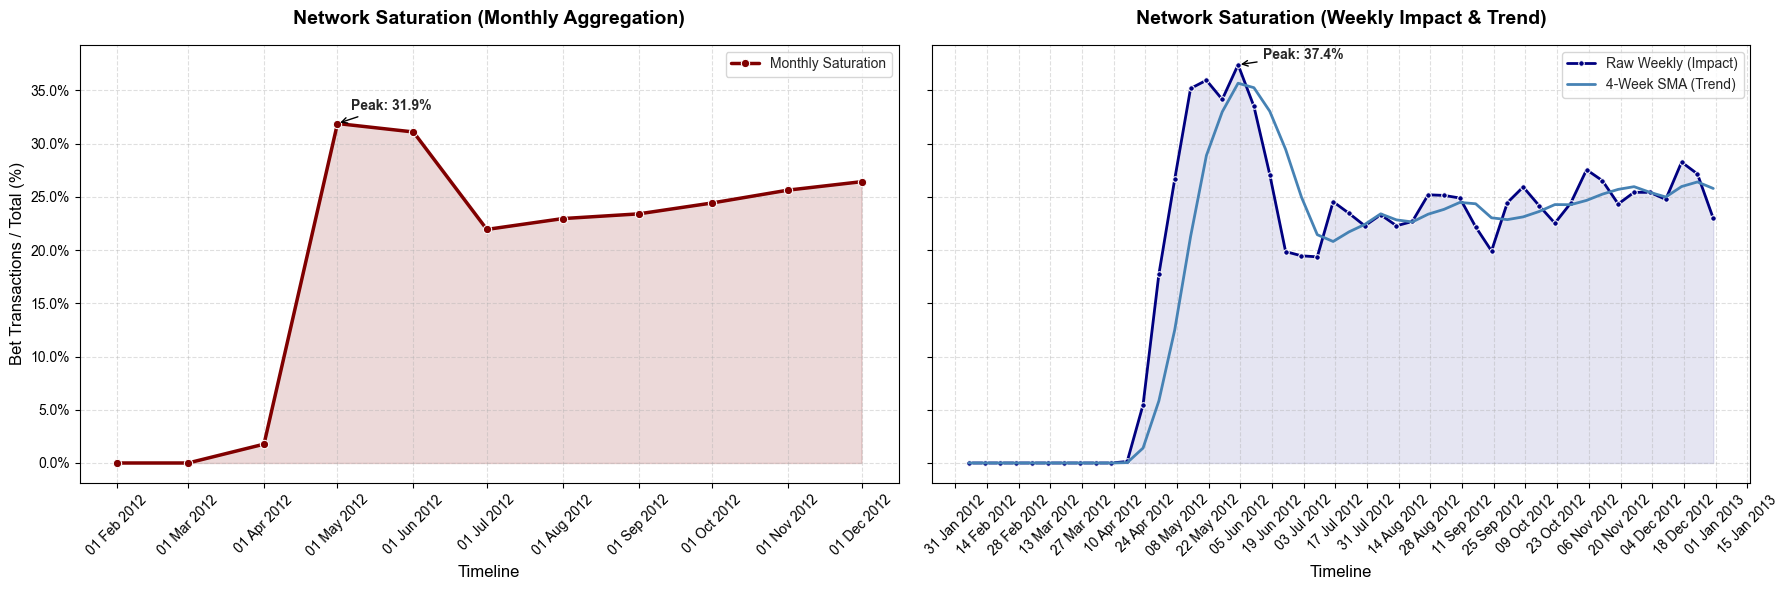

In [2]:
from src.analytics import isolate_bet_transactions, aggregate_network_saturation
from src.visualizations import plot_dual_saturation_panel

# 1. Processing dei Dati: Identifichiamo logicamente quali transazioni sono scommesse
tx_annotated = isolate_bet_transactions(tx, outputs, mapping, satoshi_dice)

# 2. Pipeline aggregativa: Deriviamo metriche macro e micro
monthly_stats = aggregate_network_saturation(tx_annotated, period='M')
weekly_stats = aggregate_network_saturation(tx_annotated, period='W')

# 3. Data Visualization
plot_dual_saturation_panel(monthly_stats, weekly_stats, start_date='2012-02-01')

### Analisi Quantitativa della Saturazione del Network

L'architettura grafica in modalità dual-panel (mensile vs. settimanale), supportata dalla tabella dei picchi di saturazione, offre una quantificazione formale dell'impatto prodotto dal protocollo SatoshiDice sulla disponibilità del *block space* di Bitcoin. 

#### Key Insights dalla Visualizzazione:
1. **Dominanza del Block Space:** L'aggregazione settimanale evidenzia il superamento della soglia del **35% di saturazione**. Al picco operativo (visibile in tabella), oltre un terzo della capacità transazionale globale di Bitcoin era assorbita esclusivamente da SatoshiDice.
2. **Visualizzazione Forense (Weekly Impact):** Nel grafico di destra, la linea **blu scuro** e l'area associata pongono l'enfasi sui picchi reali di scommesse. Questa scelta stilistica isola visivamente gli *spikes* di congestione, rendendo evidenti i momenti di massima pressione sulla rete.
3. **Analisi del Trend (SMA):** La linea **azzurra** rappresenta la media mobile a 4 settimane. Agendo come guida "smooth", permette di filtrare la volatilità settimanale e confermare un trend di crescita strutturale e organico durante tutto il 2012.

*Nota Metodologica: Ai fini della chiarezza visiva, i grafici sono stati vincolati temporalmente all'anno 2012. I dati antecedenti al deploy presentano volumi nulli che avrebbero compresso la risoluzione degli assi.*

### 2.2 Popolarità degli Indirizzi (Frequenza e Volumi)
**Obiettivo:** Valutare la popolarità di ogni indirizzo di betting con prefisso `1dice`, computando sia il numero assoluto di puntate ricevute sia il volume economico mosso in BTC (ammontare complessivo). I risultati verranno presentati attraverso visualizzazioni grafiche comparative.

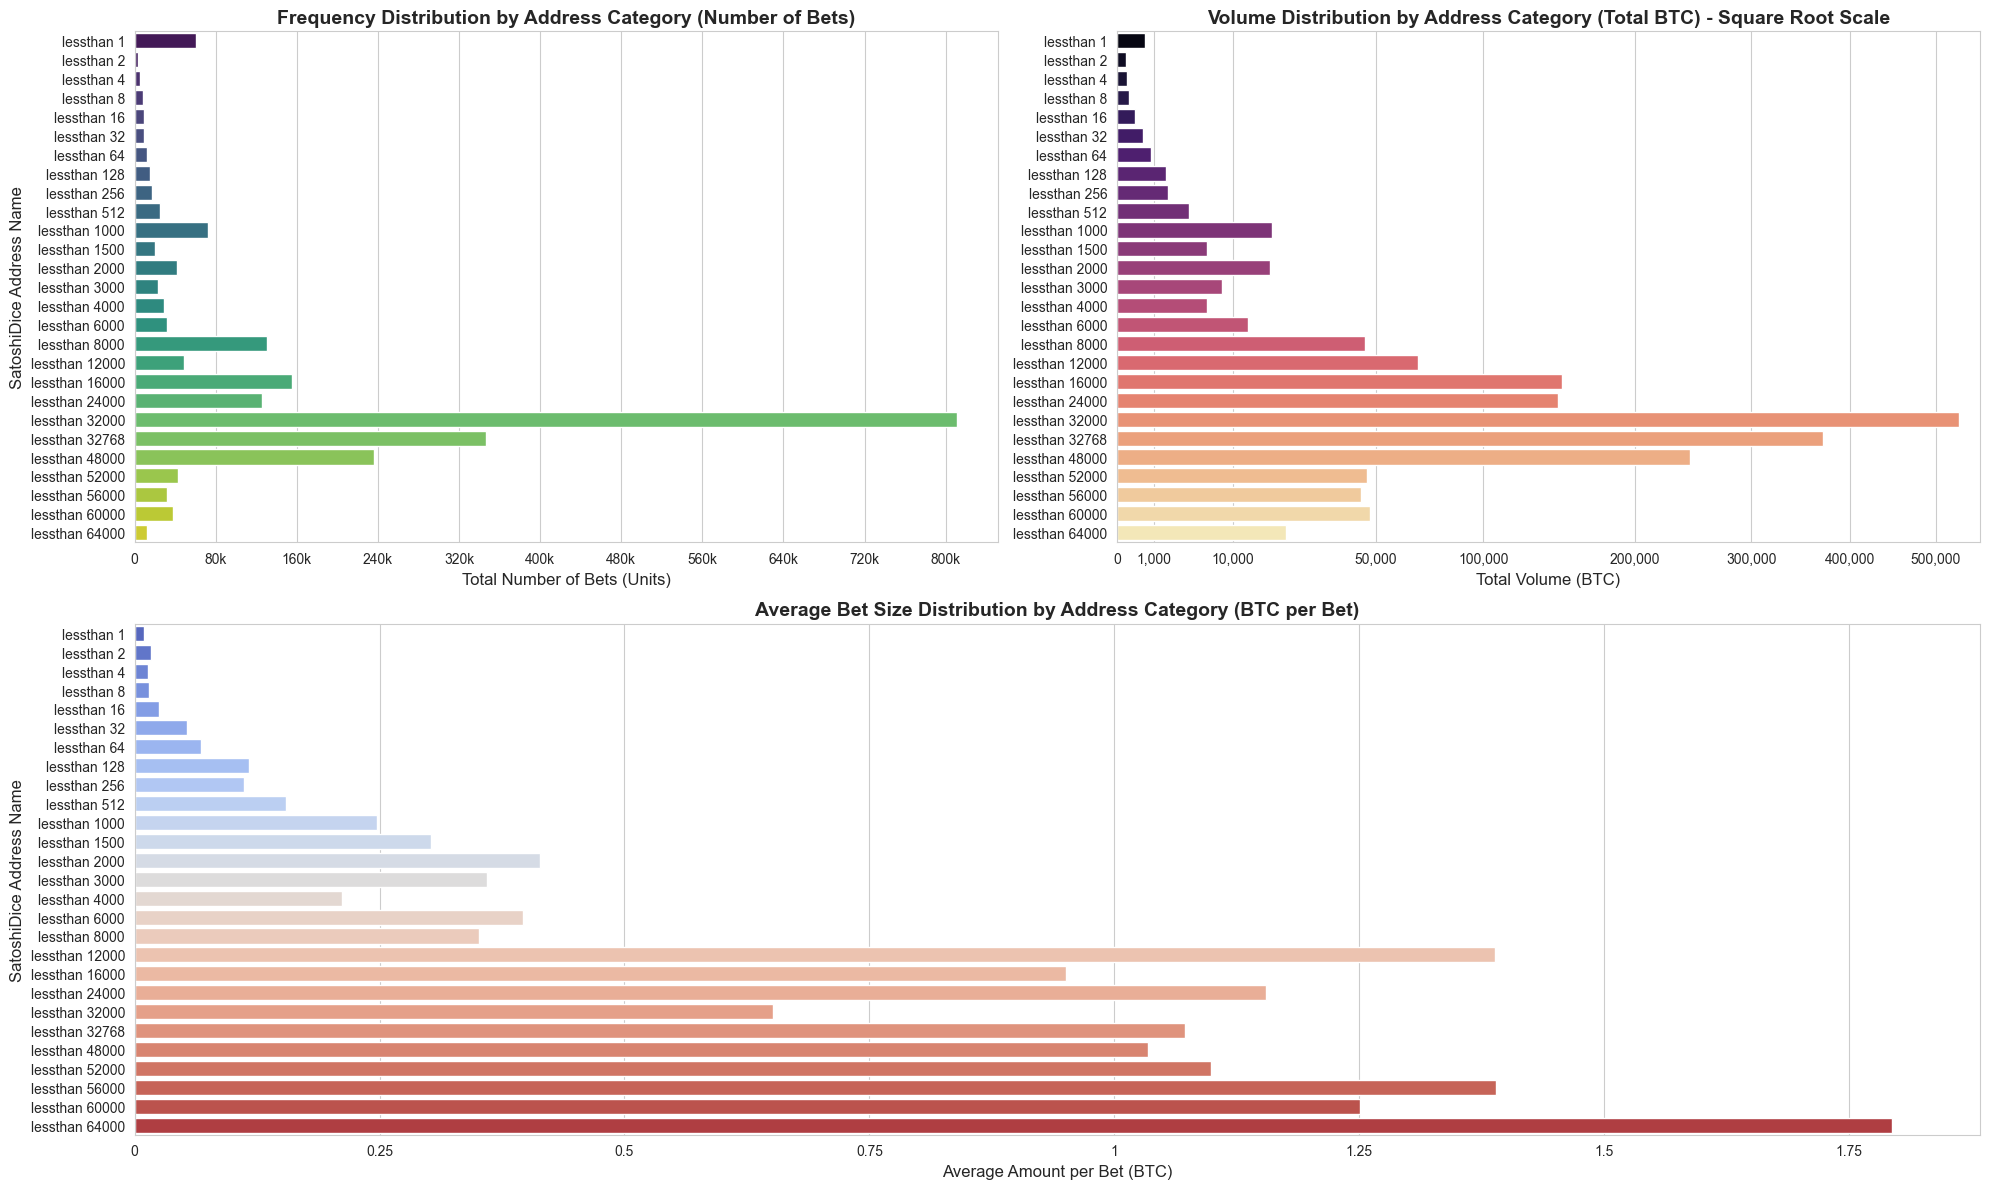

In [3]:
from src.analytics import compute_address_popularity
from src.visualizations import plot_address_popularity

# Esecuzione dell'analisi: calcolo popolarità ordinata per WinOdds per osservare la distribuzione del rischio
popularity_df = compute_address_popularity(outputs, mapping, satoshi_dice, sort_by='WinOdds', ascending=True)

# Identificazione dell'indirizzo più popolare (con più scommesse) per focalizzare l'analisi delle catene 
# utile per la seconda parte dell'analisi (Graph Analysis)
most_popular_address = popularity_df.sort_values('bet_count', ascending=False).iloc[0]['Name']

# Visualizzazione dell'intero spettro di indirizzi (27) per mappare la distribuzione
plot_address_popularity(popularity_df, top_n=27)

#### Osservazioni sulla Distribuzione del Rischio:

1. **Morfologia della Distribuzione (Skewed Distribution)**: L'ordinamento degli indirizzi per probabilità di vincita (*WinOdds*) rivela una distribuzione unimodale con un picco netto (Mode) all'indirizzo **`lessthan 32000`** (WinOdds 48.8%). Tuttavia, a differenza di una distribuzione normale simmetrica, i dati mostrano una marcata **asimmetria positiva (Right-Skewed)**, specialmente nel volume economico. Gli utenti tendono a concentrare i capitali più ingenti verso scommesse a basso rischio (coda destra del grafico), dove la densità del volume è significativamente superiore rispetto agli indirizzi speculativi.

2. **Dicotomia tra Frequenza e Volume**: Analizzando i due panel, emerge una divergenza strutturale: 
    - La **frequenza delle bet** presenta una distribuzione più "sporca", con spike rilevanti anche su quote conservative (es. 73% WinOdds) e una coda residua fissa su scommesse quasi impossibili (0.0015%).
    - Il **volume totale (BTC)** è invece fortemente sbilanciato verso la destra: il valore medio della scommessa cresce in modo quasi esponenziale man mano che il rischio diminuisce, suggerendo che il protocollo venga utilizzato come "safe heaven" per la movimentazione di fondi con alta probabilità di recupero.

3. **Il Paradosso degli Extreme Gamblers**: Nonostante la distribuzione sia centrata sul 50% e sbilanciata verso l'alto, esiste un'anomalia statistica nella coda sinistra: l'indirizzo `lessthan 1` (WinOdds minima) mantiene un'attività di circa **60.000 transazioni**. Questo suggerisce l'esistenza di cluster di utenti (o bot) orientati esclusivamente al "jackpot hunting", operando in modo totalmente asimmetrico rispetto alla massa critica del dataset.

4. **Implicazioni per la Graph Analysis**: La natura *skewed* della distribuzione conferma che il comportamento degli utenti non è casuale ma governato da una gestione del rischio ponderata (per le balene) o da algoritmi deterministici (per i micro-gamblers). Questa stratificazione sarà fondamentale nella **Sezione 3** per isolare le catene di transazioni appartenenti a differenti profili comportamentali.

### 2.3 Distanza tra Transazioni di Bet e correlato Payout

L'obiettivo di questa analisi è misurare la latenza operativa di SatoshiDice. In un sistema decentralizzato, la velocità di risposta è un fattore critico per l'esperienza utente.

#### Metodologia di Analisi (Blockchain Matching):
Per collegare una scommessa al suo payout, abbiamo implementato una logica di tracking degli **UTXO (Unspent Transaction Outputs)**:
1.  **Sorgente**: Identifichiamo il `txId` di ogni scommessa (Bet).
2.  **Tracking**: Scansioniamo il dataset degli `inputs.csv` alla ricerca di transazioni che utilizzano il `txId` della Bet come `prevTxId` (Transazione Precedente).
3.  **Identificazione**: La transazione che "spende" l'output della scommessa è, per definizione on-chain, la risposta di SatoshiDice (Payout o segnale di perdita).
4.  **Calcolo della Latenza**: Una volta formata la coppia (Bet $\rightarrow$ Payout), calcoliamo il delta in blocchi (`blockId`) e in tempo reale (`timestamp`).

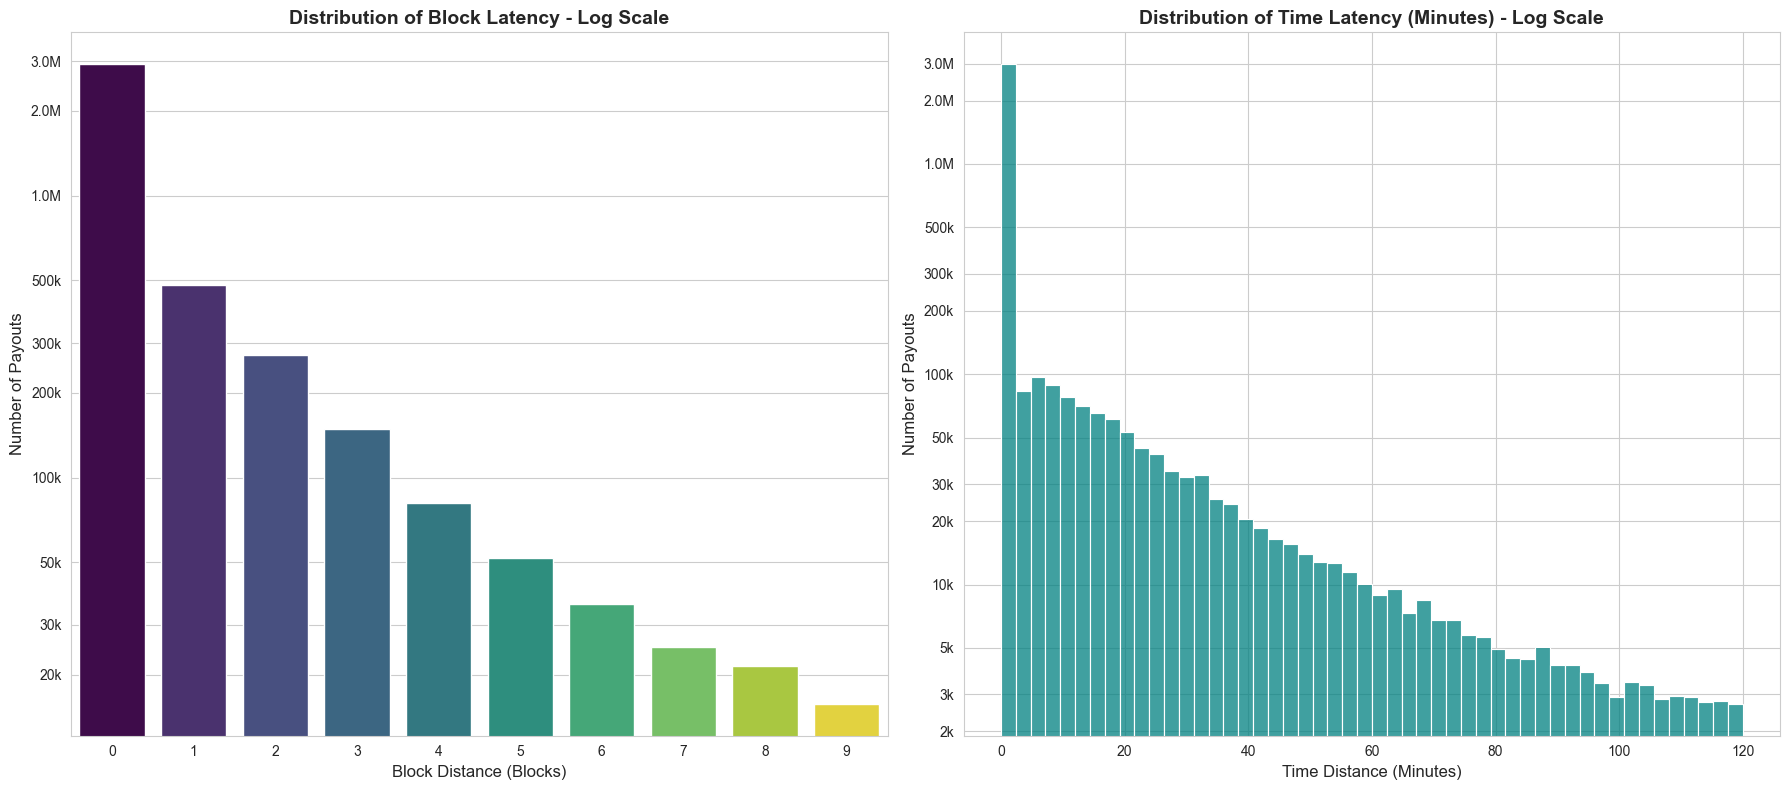

In [4]:
from src.analytics import compute_payout_latency
from src.visualizations import plot_payout_latency

# Esecuzione del matching Bet -> Payout e calcolo della latenza
payout_dist_df = compute_payout_latency(tx_annotated, inputs)

# Visualizzazione della distribuzione delle distanze
plot_payout_latency(payout_dist_df)

### Analisi della Latenza Operativa (Bet-to-Payout)

L'analisi della distanza transazionale tra la scommessa e la risposta del servizio rivela l'efficienza algoritmica di SatoshiDice e la sua capacità di reazione on-chain.

#### Key Findings:
1. **Esecuzione "Same-Block" Dominante**: Il grafico della *Block Latency* mostra che la stragrande maggioranza dei payout avviene con una distanza di **0 blocchi**. Questo indica che SatoshiDice era in grado di intercettare le transazioni di bet nel *mempool* e inserire la transazione di risposta nello stesso blocco minato, garantendo un'esperienza quasi istantanea per l'epoca.
2. **Distribuzione Temporale**: La latenza temporale segue una distribuzione con un picco marcato nei primi **10-20 minuti**. Questo delta riflette il tempo medio di conferma di un blocco Bitcoin. La presenza di una coda lunga suggerisce casi in cui la transazione di payout è rimasta in attesa di conferma a causa di congestione della rete o fee insufficienti.
3. **Affidabilità del Protocollo**: La quasi totalità delle risposte viene evasa entro i primi 3 blocchi (circa 30 minuti). Questa velocità operativa è stata uno dei fattori chiave della popolarità di SatoshiDice, rendendolo di fatto il primo servizio di gambling "real-time" basato interamente su blockchain senza necessità di depositi centralizzati.
4. **Automazione On-Chain**: Il legame diretto tra Input e Output (verificato tramite il matching del `prevTxId`) conferma che l'intero sistema era automatizzato: non appena una bet veniva rilevata dai nodi del servizio, veniva generata programmaticamente la transazione di payout, eliminando l'intervento umano nel ciclo di gioco.

### 2.4 Profilazione Comportamentale dei Top 3 Indirizzi

In questa fase l'analisi si sposta da una visione d'insieme a un'ispezione granulare dei **tre indirizzi SatoshiDice più popolari** identificati nella sezione precedente. L'obiettivo è intercettare regolarità comportamentali, pattern di automazione (bot) e dinamiche di allocazione delle risorse (fee).

Per ciascuno dei 3 indirizzi target, verranno indagate tre dimensioni analitiche:

1.  **Distribuzione Temporale delle Bet**: Analizzeremo come le puntate si distribuiscono su diverse scale temporali (ora del giorno, giorno della settimana). Questo permette di distinguere tra attività organica (umana) e attività costante/algoritmica.
2.  **Analisi di Correlazione Fee vs Amount**: Verificheremo se esiste un legame statistico tra l'importo scommesso (*Amount*) e la commissione di transazione pagata (*Miner Fee*). Una correlazione elevata potrebbe indicare una gestione prioritaria delle scommesse più pesanti, mentre una fee fissa suggerisce l'uso di wallet standard o script.
3.  **Intervallo tra Bet Consecutive**: Studieremo il tempo intercorso tra una puntata e la successiva all'interno dello stesso cluster di indirizzo. La presenza di picchi di frequenza su intervalli di tempo millimetrici o perfettamente regolari è un marker definitivo di attività bot automatizzata.

Questa profilazione è propedeutica alla successiva ricostruzione delle catene di gioco nella Sezione 3.

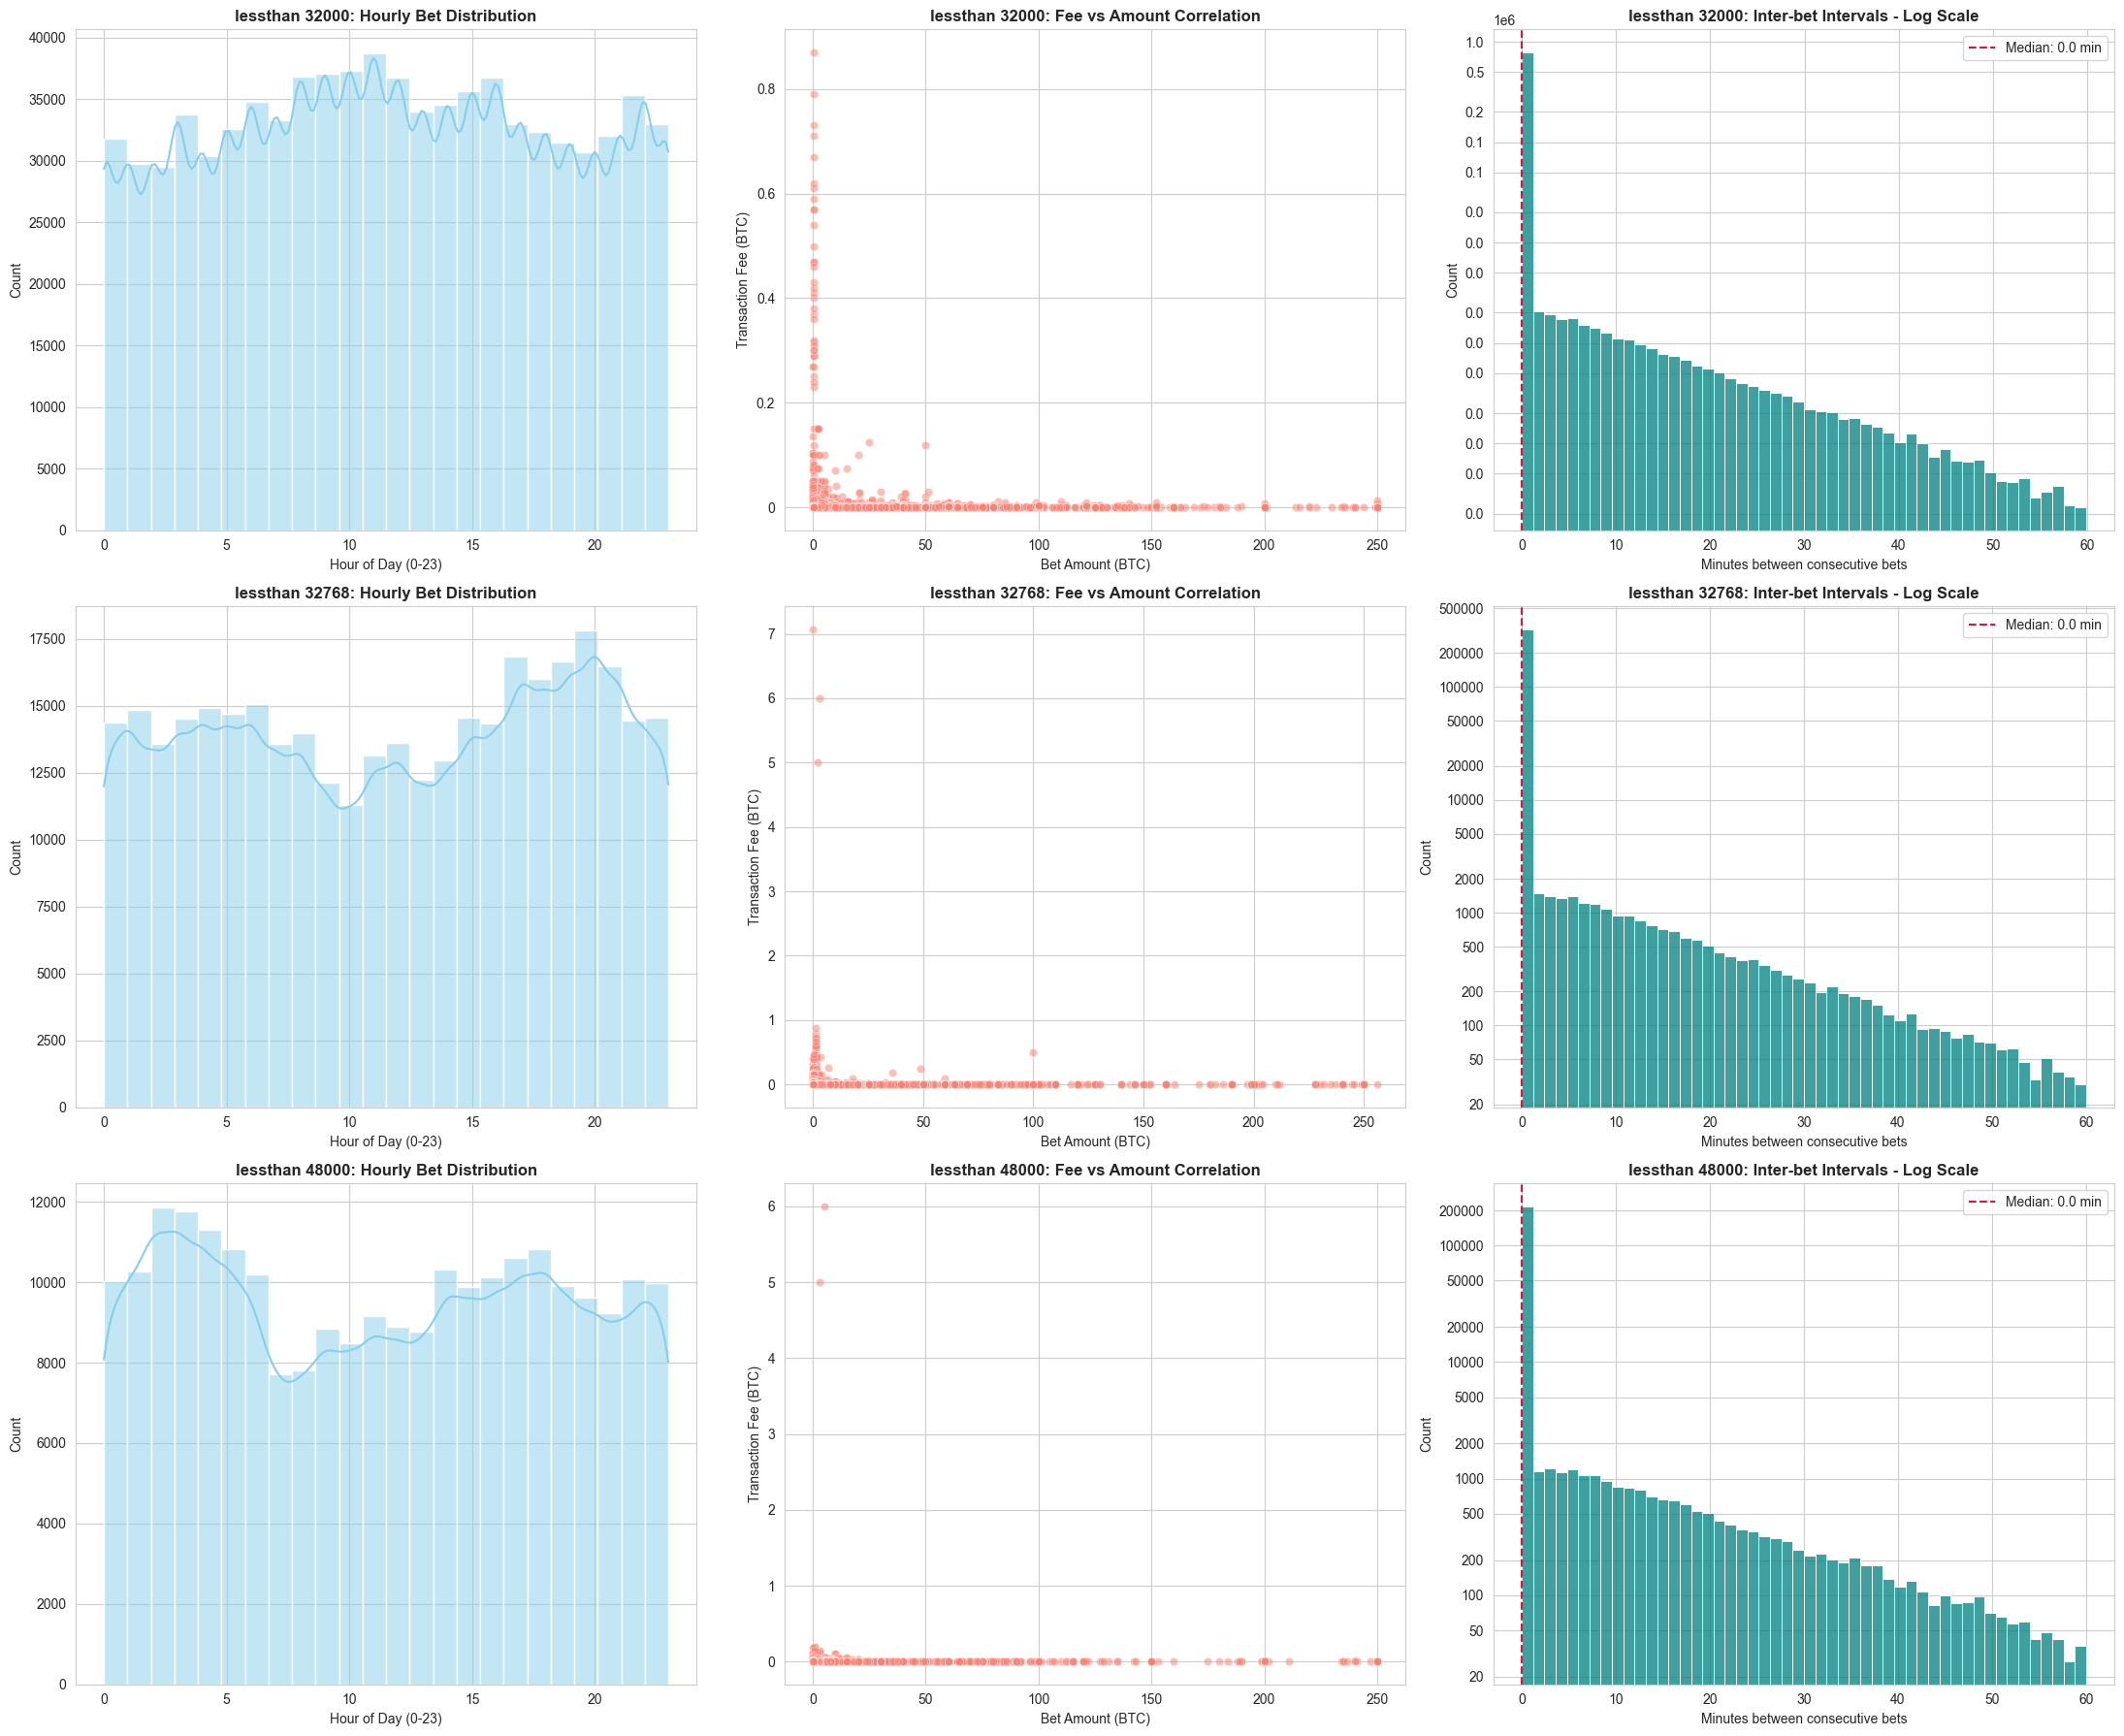

In [5]:
from src.analytics import get_behavioral_data
from src.visualizations import plot_behavioral_profiling

# 1. Identificazione dei Top 3 indirizzi (già calcolati in popularity_df)
top_3_df = popularity_df.nlargest(3, 'bet_count')
top_3_hashes = top_3_df['hash'].tolist()
top_3_names = top_3_df['Name'].tolist()

# 2. Estrazione dei dati comportamentali per ciascuno dei 3 indirizzi
behavioral_results = {}
for h, name in zip(top_3_hashes, top_3_names):
    behavioral_results[name] = get_behavioral_data(tx_annotated, h, outputs, mapping)

# 3. Visualizzazione del pannello di profilazione comparativo
plot_behavioral_profiling(behavioral_results)


In [6]:
# Analisi specifica: Percentuale di scommesse con intervalli inferiori a 10 secondi per il più popolare
s = behavioral_results[top_3_names[0]]['time_delta']

# Calcolo della percentuale di scommesse con intervalli inferiori a 10 secondi
percentuale = (s < 10).sum() / s.count() * 100

print(f"{top_3_names[0]} - Percentuale scommesse con intervallo inferiore a 10sec: {percentuale:.2f}%")

lessthan 32000 - Percentuale scommesse con intervallo inferiore a 10sec: 96.77%


#### Riscontri Forensi ed Evidenze Empiriche:

Dall'ispezione dei dati reali per gli indirizzi `lessthan 32000`, `32768` e `48000`, emergono conclusioni univoche sulla natura del network:

1. **Dominanza Assoluta di Automazione (Inter-bet Intervals)**: 
   - I dati rivelano che oltre il **96% delle scommesse** sull'indirizzo più popolare (`lessthan 32000`) avviene con un intervallo inferiore ai **10 secondi** dalla precedente.
   - La **mediana dell'intervallo è pari a 0 secondi** (molteplici bet nello stesso istante). Questa è l'evidenza definitiva di un ecosistema dominato da **Bot ad alta frequenza** e script automatizzati che gestiscono flussi massivi di transazioni.

2. **Assenza di Strategia Economica Reattiva (Correlation)**:
   - Il coefficiente di correlazione tra Fee e Amount è prossimo allo zero (**~0.01**). Questo indica che i giocatori (o i bot) non modulano la commissione di rete in base al valore scommesso. 
   - L'uso di **fee fisse o standardizzate** (indipendentemente dal fatto che si scommetta 0.1 o 10 BTC) suggerisce l'impiego di wallet pre-configurati o software di gioco che non ottimizzano la priorità on-chain in modo dinamico.

3. **Distribuzione temporale**:
   - Sebbene si notino dei picchi in ore specifiche (es. ore 11:00 per l'indirizzo dominante), l'attività non scende mai verso lo zero durante le ore notturne globali. Questa persistenza 24/7 conferma che il volume di SatoshiDice non era alimentato solo da giocatori occasionali, ma da **processi batch** e algoritmi di gioco sistematico.

Questi risultati dimostrano che SatoshiDice ha rappresentato il primo vero stress-test per Bitcoin, non per un afflusso massivo di persone, ma per la nascita di una **economia di bot automatizzati** on-chain.

## 3. Analisi di sequenze di bet (Graph Reconstruction)

In questa sezione verranno ripristinate le catene logiche di interazione con il protocollo. L'obiettivo è ricostruire le "sessioni di gioco" degli utenti, tracciando come i fondi si muovono da una puntata alla successiva.

In linea con i requisiti di progetto, l'analisi si restringe unicamente alle **"Simple Bets"** inviate all'indirizzo `1dice` dominante (`lessthan 32000`). Una *simple bet* è definita come una transazione caratterizzata da:
- **Esattamente 1 Input** (proveniente da un wallet o dal resto di una puntata precedente).
- **Esattamente 2 Output**: uno destinato a SatoshiDice e l'altro identificato come output di resto (*Change*).

#### Workflow Algoritmico e Modellazione a Grafo
Per estrarre le catene, è stato modellato un **Grafo Diretto $G = (V,E)$** con la seguente topologia:
1. **Nodi ($V$)**: Ogni nodo rappresenta una singola *simple bet*.
2. **Archi ($E$)**: Esiste un arco diretto $(v_i, v_j)$ se e solo se l'unico input della bet $v_j$ consuma esattamente l'output di resto generato dalla bet $v_i$.
3. **Etichette (Edge Attributes)**: A ciascun arco è stato associato l'hash dell'indirizzo Bitcoin del resto, che funge da connettore tra le due transazioni.

Poiché sulla blockchain un output non speso (UTXO) può essere consumato una sola volta (out-degree $\le 1$) e ogni *simple bet* possiede un solo input (in-degree $\le 1$), ogni componente debolmente connessa in questo grafo rappresenta matematicamente un **cammino lineare**, definendo così in modo univoco una "catena di scommesse".


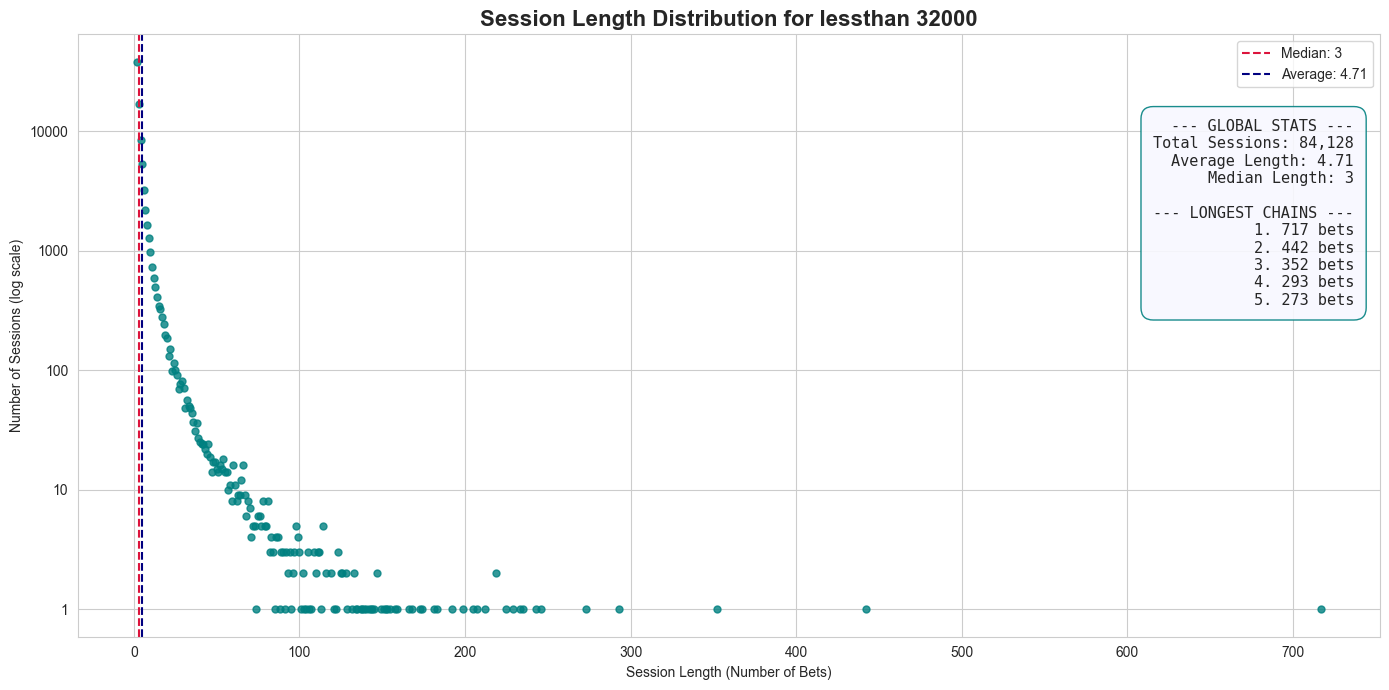

In [7]:
from src.analytics import reconstruct_bet_chains
from src.visualizations import plot_chain_length_distribution

# 1. Ricostruzione delle catene (Graph Analysis)
# Passiamo solo inputs, outputs, mapping e satoshi_dice.
chains_df, _ = reconstruct_bet_chains(inputs, outputs, mapping, satoshi_dice, target_name=most_popular_address)

# 2. Visualizzazione della distribuzione delle lunghezze delle sessioni
plot_chain_length_distribution(chains_df, most_popular_address)

### Risultati della Ricostruzione Topologica (Path Analysis)

L'algoritmo di ricostruzione basato sul tracciamento degli UTXO di resto ha permesso di raggruppare transazioni individuali in vere e proprie sessioni continuative. 

**Analisi della Distribuzione delle Lunghezze:**
1. **Morfologia a Coda Lunga (Heavy-Tail)**: La rappresentazione grafica (con frequenze in scala logaritmica) evidenzia come la stragrande maggioranza delle catene sia di breve durata (2-5 scommesse). Tuttavia, il sistema fa emergere una *long-tail* significativa, con catene massimali che superano le **centinaia di nodi** (es. 717 scommesse in una singola sequenza ininterrotta). 
2. **Identificazione di Pattern Non-Umani**: La presenza di sequenze così lunghe e ininterrotte, dove il resto viene sistematicamente re-investito nell'input successivo per centinaia di iterazioni, suggerisce fortemente l'impiego di bot o script automatizzati ottimizzati per il gambling, piuttosto che giocatori umani manuali.
3. **Persistenza e Efficienza del Protocollo**: Il successo di queste catene lunghissime conferma empiricamente i risultati sulla *Latenza* ottenuti in precedenza. SatoshiDice processava e inviava i payout così velocemente che gli script automatizzati potevano alimentare la transazione successiva quasi in tempo reale, senza incorrere in colli di bottiglia legati all'attesa di conferme (unconfirmed parent tx).

Le catene massimali identificate (*longest paths*) costituiscono un input perfetto per la successiva fase di de-anonimizzazione OSINT, in quanto forniscono un volume elevato di *change addresses* associati alla medesima entità logica.


## 4 Metodologia di De-anonimizzazione OSINT

In questa fase finale, il sistema abbandona l'analisi puramente topologica della blockchain per integrare intelligence esterna proveniente da **WalletExplorer**. L'obiettivo è verificare se le catene di scommesse più lunghe (identificate nella Sezione 3) siano riconducibili a un unico wallet controllato da un singolo utente o se coinvolgano una frammentazione di entità diverse.

#### Requisiti di Analisi:
Per le top $h$ catene di lunghezza massima, il sistema esegue:
1. **Estrazione degli Indirizzi di Collegamento**: Isolamento di tutti gli indirizzi di resto (*change addresses*) che fungono da archi tra le scommesse consecutive della catena.
2. **Scraping Heuristic Clustering**: Utilizzo di un'infrastruttura **Selenium Headless** per interrogare WalletExplorer e mappare ogni indirizzo al suo cluster multi-input di appartenenza.
3. **Consolidamento KPI**: Generazione di una **Comprehensive Evaluation Table** che traccia la lunghezza, la popolazione di indirizzi, il numero di wallet distinti e la dominanza dell'entità principale.

*Nota: Per garantire l'efficienza e il rispetto dei limiti del servizio WalletExplorer, è stato implementato un sistema di caching locale (`wallet_mapping.csv`)*

In [8]:
# Selezione delle Top H catene per la fase di scraping
h = 10
top_chains = chains_df.sort_values('length', ascending=False).head(h).copy()
print(f"Isolate le top {h} catene per l'analisi forense.")
print(top_chains[['length', 'edges_count']])

Isolate le top 10 catene per l'analisi forense.
       length  edges_count
10937     717          716
11804     442          441
10125     352          351
8192      293          292
4533      273          272
12093     246          245
62657     243          242
10358     235          234
8785      233          232
8748      229          228


In [9]:
from src.analytics import analyze_chain_wallets

# 1. Auditing delle Top H catene (De-anonimizzazione OSINT)
# Definiamo il percorso per il file di cache dei wallet
wallet_mapping_path = os.path.join(project_root, 'data', 'processed', 'wallet_mapping.csv')

# Esecuzione della pipeline di scraping e analisi
# Passiamo le top_chains identificate nello step precedente
evaluation_table = analyze_chain_wallets(top_chains, mapping_file=wallet_mapping_path, force_refresh=False)

styled = (
    evaluation_table.style
    .set_caption("Comprehensive Entity Evaluation Matrix")
    .format({'Predominant_Percentage': '{:.2f}%'})
    .set_properties(**{
        'text-align': 'center'
    })
)

styled

All addresses are already cached. Use force_refresh=True to download them again.


,Chain_ID,Length,Total_Addresses,Distinct_Wallets,Predominant_Wallet,Predominant_Percentage,Traceability_Conclusion
0,Chain_10937,717,716,76,[0025d633f8],50.14%,Multiple Entities (Fragmented)
1,Chain_11804,442,441,1,[00002c4379],100.00%,Single Entity (Traceable)
2,Chain_10125,352,351,5,[0025d633f8],79.20%,Multiple Entities (Fragmented)
3,Chain_8192,293,292,5,[000f35cb33],75.68%,Multiple Entities (Fragmented)
4,Chain_4533,273,272,2,[000305c34c],99.63%,Multiple Entities (Fragmented)
5,Chain_12093,246,245,20,[001b861dc5],54.29%,Multiple Entities (Fragmented)
6,Chain_62657,243,242,25,[004bf37491],71.90%,Multiple Entities (Fragmented)
7,Chain_10358,235,234,11,[0005f727db],88.03%,Multiple Entities (Fragmented)
8,Chain_8785,233,232,3,[0012ea9acf],93.97%,Multiple Entities (Fragmented)
9,Chain_8748,229,228,36,[0012ea9acf],78.51%,Multiple Entities (Fragmented)


### Conclusioni sull'Analisi delle Entità

I risultati riportati nella tabella sopra permettono di trarre conclusioni definitive sulla natura delle sessioni di gioco prolungate su SatoshiDice:

1. **Integrità del Wallet**: Un'alta percentuale di predominanza del wallet (prossima al 100%) conferma che la catena appartiene a un unico utente/entità che reinveste sistematicamente i propri fondi. 
2. **De-anonimizzazione**: Se il `Predominant_Wallet` restituisce un nome esplicito (es. un Exchange o un servizio), siamo in grado di attribuire l'intera sessione di gioco a un utente di quella specifica piattaforma.
3. **Frammentazione**: Se compaiono più wallet distinti, la catena potrebbe aver subito dei passaggi di proprietà o l'utente sta utilizzando tecniche di rimescolamento (mixer) tra una scommessa e l'altra.

Questo workflow completa l’obiettivo del progetto BetFlow, dimostrando come l’integrazione tra analisi dei grafi e web scraping consenta di analizzare strutture transazionali complesse e di evidenziare possibili collegamenti tra entità anche in protocolli ad alta frequenza come SatoshiDice.